In [1]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `d:\SeqFISH+Processing_project\UntanglingBarcodes\figure_generating_notebooks\Fig2D_ect`


In [2]:
using CSV, DataFrames, Plots, NearestNeighbors, GLM, LinearAlgebra, StatsBase

In [3]:
cb = DataFrame(CSV.File("codebooks/full_RS_q11_k7_cb.csv"));

In [4]:
ge_cb = cb[cb.gene .!= "negative_control", :];

In [5]:
nc_cb = cb[cb.gene .== "negative_control", :];

In [6]:
function get_binary_cb(cb)
    _cb = cb[:, Not(:gene)]
    npseudocolors = maximum(Array(_cb))
    nblocks = ncol(_cb)# - 1

    binary_cb = BitArray(zeros(nrow(_cb), npseudocolors*nblocks))
    
    for (i, cw) in enumerate(eachrow(_cb))
        for (r, pc) in enumerate(cw)
            if pc != 0
                #println("pc: ", pc)
                #println(npseudocolors*(r-1))
                binary_cb[i, pc + npseudocolors*(r-1)] = 1
            end
        end
    end
    return binary_cb
end

get_binary_cb (generic function with 1 method)

In [7]:
binary_ge_cb = get_binary_cb(ge_cb);

In [8]:
binary_nc_cb = get_binary_cb(nc_cb);

In [9]:
dcd_files = readdir("decoded")
dcd_files_no_neg_ctrl = sort([fname for fname in dcd_files if occursin("no_neg_ctrl", fname) & occursin("dr0", fname) & occursin("lf7", fname) & occursin("cell", fname)])
dcd_files_neg_ctrl = sort([fname for fname in dcd_files if ~occursin("no_neg_ctrl", fname) & occursin("dr0", fname) & occursin("lf7", fname) & occursin("cell", fname)]);

In [10]:
last_43(str) = str[(end-43):end]

last_43 (generic function with 1 method)

In [11]:
files_same = last_43.(dcd_files_no_neg_ctrl) .== last_43.(dcd_files_neg_ctrl)
dcd_files_no_neg_ctrl = dcd_files_no_neg_ctrl[files_same]
dcd_files_neg_ctrl= dcd_files_neg_ctrl[files_same]
all(last_43.(dcd_files_no_neg_ctrl) .== last_43.(dcd_files_neg_ctrl))

true

In [12]:
length(dcd_files_no_neg_ctrl)

217

In [13]:
length(dcd_files_neg_ctrl)

217

In [48]:
nc_bcs = []
ge_bcs = []
proximity_freqs = zeros(nrow(ge_cb), nrow(ge_cb))
proximity_freqs_sr2 = zeros(nrow(ge_cb), nrow(ge_cb))

for i in 1:length(dcd_files_neg_ctrl)
    #println("i:", i)
    fname_neg_ctrl = dcd_files_neg_ctrl[i]
    fname_no_neg_ctrl = dcd_files_no_neg_ctrl[i]
    #println(fname_no_neg_ctrl)
    #println(fname_neg_ctrl)
    @assert(fname_neg_ctrl[(end-43):end] == fname_no_neg_ctrl[(end-43):end])

    dcd_neg_ctrl = DataFrame(CSV.File("decoded/" * fname_neg_ctrl))
    dcd_no_neg_ctrl = DataFrame(CSV.File("decoded/" * fname_no_neg_ctrl))
    
    gene_coords_neg_ctrl = dcd_neg_ctrl[dcd_neg_ctrl.gene .== "negative_control", ["gene", "gene_number", "x", "y"]]
    gene_coords_no_neg_ctrl = dcd_no_neg_ctrl[:, ["gene", "gene_number", "x", "y"]]

    push!(nc_bcs, gene_coords_neg_ctrl)
    push!(ge_bcs, gene_coords_no_neg_ctrl)

    if nrow(dcd_no_neg_ctrl) > 0
        tree = KDTree(Matrix(dcd_no_neg_ctrl[:,[:x, :y]])')
        nbrs = inrange(tree, Matrix(dcd_no_neg_ctrl[:,[:x, :y]])', 1)
        nbrs_sr2 = inrange(tree, Matrix(dcd_no_neg_ctrl[:,[:x, :y]])', 2)
        for (i, i_nbrs) in enumerate(nbrs)
            proximity_freqs[dcd_no_neg_ctrl[i, "gene_number"], dcd_no_neg_ctrl[i_nbrs, "gene_number"]] .+= 1
        end
        for (i, i_nbrs) in enumerate(nbrs_sr2)
            proximity_freqs_sr2[dcd_no_neg_ctrl[i, "gene_number"], dcd_no_neg_ctrl[i_nbrs, "gene_number"]] .+= 1
        end
    end
end

In [49]:
sum(nrow.(ge_bcs) .> 0)

217

In [50]:
ge_bcs_concat = vcat(ge_bcs...);

In [51]:
nc_bcs_concat = vcat(nc_bcs...);

In [52]:
nc_bc_detections = sort(combine(nrow, groupby(nc_bcs_concat, :gene_number)), :gene_number);

In [53]:
ge_bc_detections = combine(nrow, groupby(ge_bcs_concat, [:gene_number, :gene]))
sort!(ge_bc_detections, :gene_number);

In [54]:
expr_weighted_ge_cws = ge_bc_detections[:, "nrow"] .* binary_ge_cb;

In [55]:
double_overlaps = zeros(271,271, 1829)
for nc in 1:1829, i in 1:271, j in (i+1):271
    double_overlaps[i,j,nc] = (binary_ge_cb[i, :] .| binary_ge_cb[j, :])' * binary_nc_cb[nc,:]
end

In [56]:
maximum(double_overlaps)

4.0

In [57]:
#double_recomb_freq 
ρ₄₁ = reshape(sum(proximity_freqs .* (double_overlaps .== 4), dims=[1,2]), 1829)
#double_recomb_freq_sr2 
ρ₄₂ = reshape(sum(proximity_freqs_sr2 .* (double_overlaps .== 4), dims=[1,2]), 1829);

In [58]:
#near_recomb_freq
ρ₃₁ = reshape(sum(proximity_freqs .* (double_overlaps .== 3), dims=[1,2]), 1829);
#near_recomb_freq_sr2 
ρ₃₂= reshape(sum(proximity_freqs_sr2 .* (double_overlaps .== 3), dims=[1,2]), 1829);

In [59]:
CGd = binary_nc_cb * binary_ge_cb' * ge_bc_detections[:, "nrow"];

In [60]:
df = DataFrame("nc_counts" => nc_bc_detections[!, "nrow"], "CGd" => CGd, "ρ₃₁" => ρ₃₁, "ρ₄₁" => ρ₄₁, "ρ₃₂" => ρ₃₂, "ρ₄₂" => ρ₄₂)

Row,nc_counts,CGd,ρ₃₁,ρ₄₁,ρ₃₂,ρ₄₂
,Int64,Int64,Float64,Float64,Float64,Float64
1,92,366999,110.0,0.0,369.0,0.0
2,494,575824,6299.0,0.0,23628.0,0.0
3,192,459256,281.0,0.0,877.0,0.0
4,496,489483,1203.0,0.0,4202.0,0.0
5,162,444797,0.0,0.0,0.0,0.0
6,92,432705,106.0,0.0,384.0,0.0
7,66,331179,526.0,0.0,2163.0,0.0
8,297,313051,1262.0,59.0,4658.0,212.0
9,172,401098,660.0,0.0,2308.0,0.0


In [67]:
#model = lm(@formula(nc_counts ~ expr_prox + near_recomb_freq + recomb_freq + near_recomb_freq_sr2 + recomb_freq_sr2), df)

model = lm(@formula(nc_counts ~ CGd + ρ₃₁ + ρ₄₁ + ρ₃₂ + ρ₄₂), df)
r2(model)

0.5125006550000168

In [68]:
model

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

nc_counts ~ 1 + CGd + ρ₃₁ + ρ₄₁ + ρ₃₂ + ρ₄₂

Coefficients:
───────────────────────────────────────────────────────────────────────────────────────
                     Coef.   Std. Error       t  Pr(>|t|)      Lower 95%      Upper 95%
───────────────────────────────────────────────────────────────────────────────────────
(Intercept)  -69.2925       13.2729       -5.22    <1e-06  -95.3242       -43.2609
CGd            0.000592056   4.01467e-5   14.75    <1e-45    0.000513317    0.000670794
ρ₃₁            0.903248      0.0763744    11.83    <1e-30    0.753458       1.05304
ρ₄₁           -4.04928       1.71456      -2.36    0.0183   -7.412         -0.686567
ρ₃₂           -0.210689      0.0206415   -10.21    <1e-23   -0.251172      -0.170206
ρ₄₂            1.67205       0.464926      3.60    0.0003    0.760206    

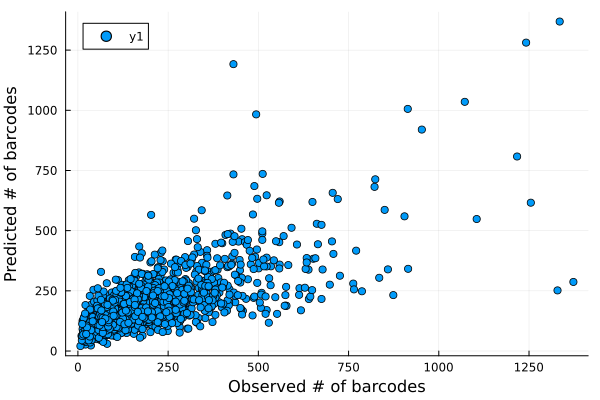

In [69]:
scatter(df[!, "nc_counts"], predict(model))
xlabel!("Observed # of barcodes")
ylabel!("Predicted # of barcodes")

In [71]:
df[!, "predicted"] =predict(model)

1829-element Vector{Float64}:
  169.6044497057258
  983.0310199103533
  271.6512392904382
  421.80164343445097
  194.05209377260434
  201.7327371170768
  146.17240358328445
  390.1285122739605
  278.0537455858817
  175.22401434183433
    ⋮
  367.84506688285364
  205.20186769913357
  123.4328675407189
  139.45626446839833
  106.45518920469956
 1191.7173520375109
  120.46599525852992
  191.42567266159398
  116.93958574815356

In [72]:
CSV.write("nc_barcoded_detection_obs_pred_mod.csv", df) 

"nc_barcoded_detection_obs_pred_mod.csv"